# **Day 2.1: Multi-Layer Perceptrons (MLPs)**
**Module Theme:** From Single Neuron to Deep Networks  
**Estimated Time:** 1.0 hour  
**Prerequisites:** Day 1 - Neural Network Fundamentals

In [3]:
%%html
<style>
.jp-RenderedMarkdown table {
    font-size: 16px !important;
    line-height: 1.6 !important;
    border-collapse: collapse !important;
    width: 100% !important;
    margin: 20px 0 !important;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
}

.jp-RenderedMarkdown table th {
    background-color: #2c3e50 !important;
    color: white !important;
    padding: 15px 20px !important;
    text-align: left !important;
    font-weight: 600 !important;
    font-size: 16px !important;
    border: none !important;
}

.jp-RenderedMarkdown table td {
    padding: 15px 20px !important;
    border: none !important;
    border-bottom: 1px solid #e0e0e0 !important;
    vertical-align: top !important;
}

.jp-RenderedMarkdown table tr:nth-child(even) {
    background-color: #f8f9fa !important;
}

.jp-RenderedMarkdown table tr:nth-child(odd) {
    background-color: white !important;
}

.jp-RenderedMarkdown table tr:hover {
    background-color: #e3f2fd !important;
}

/* Style the first column differently */
.jp-RenderedMarkdown table td:first-child {
    font-weight: 600 !important;
    color: #2c3e50 !important;
    background-color: #f5f5f5 !important;
}

.jp-RenderedMarkdown table tr:nth-child(even) td:first-child {
    background-color: #eeeeee !important;
}
</style>

## **📚 Table of Contents**
- [2.1.1 Building ANNs: Layers, Weights, Biases](#211-building-anns-layers-weights-biases)
- [2.1.2 Feedforward Process: Information Flow](#212-feedforward-process-information-flow)
- [Summary & Transition to Note 2.2](#summary--transition-to-note-22)

## **2.1.1 Building ANNs: Layers, Weights, Biases**
*Estimated Time: 30 minutes*

### **What Makes a Network "Deep"?**

A **Multi-Layer Perceptron (MLP)**, also known as a deep Artificial Neural Network (ANN), is simply a network with **one or more layers of neurons between the input and output layers**. These are called **hidden layers**.

<div align="center">
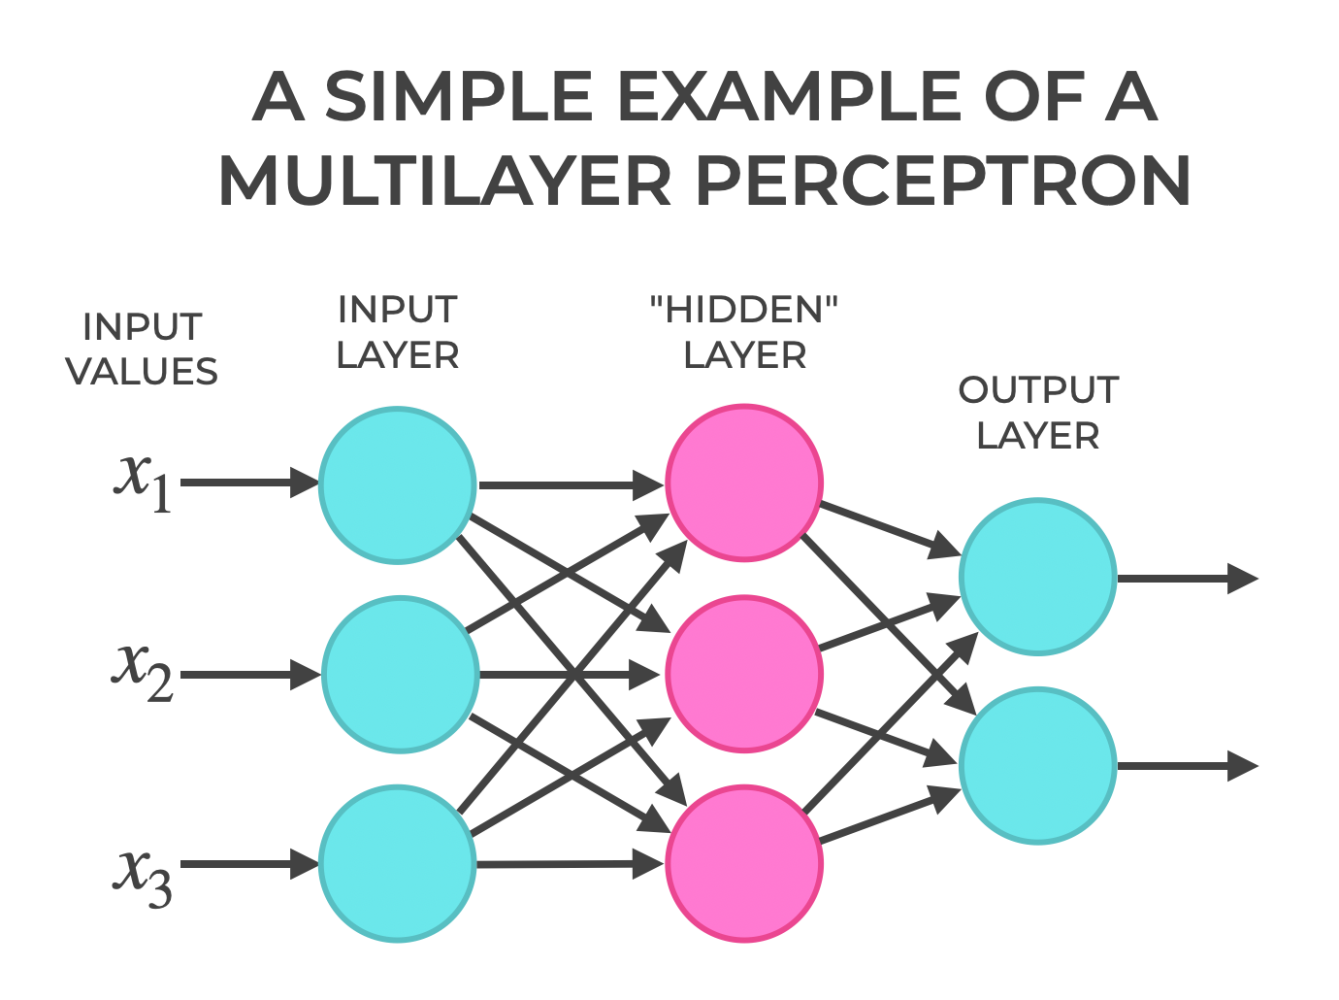
</div>

**Why "Deep"?** A network is considered "deep" if it has **at two or more hidden layers**. Modern deep learning models can have hundreds of hidden layers!

<div align="center">
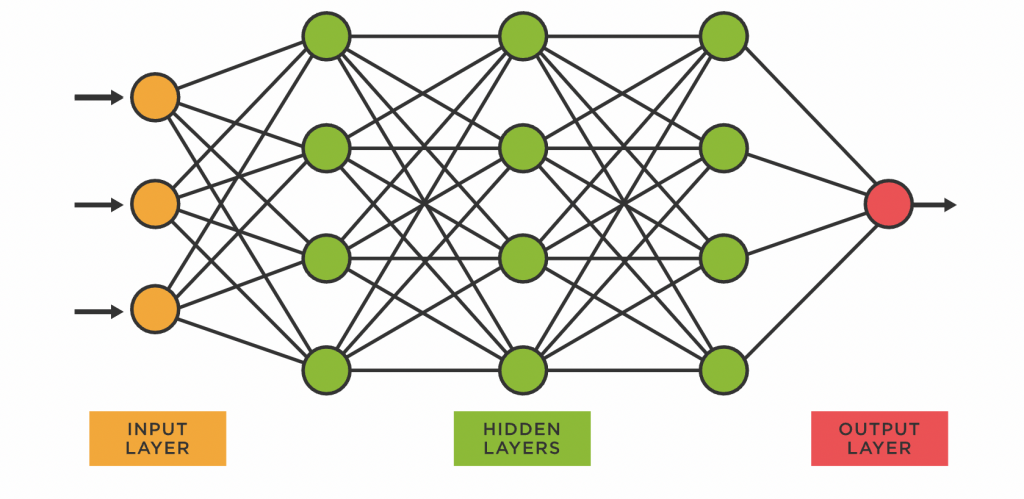
</div>

### **The Architecture: Building Your Neural Skyscraper**

Think of building a neural network like constructing a skyscraper - each floor (layer) serves a specific purpose:

#### **🏢 Layer-by-Layer Breakdown:**

**1. Input Layer (Ground Floor - Data Entry)**
- This isn't really a layer of neurons - it's a "passthrough" layer
- Takes in your input features (e.g., 30 features from breast cancer dataset)
- Number of nodes = number of features in your data
- **No computation happens here** - just data distribution

**2. Hidden Layers (Floors 2-N - The Magic Happens Here)**
- Each hidden layer is a collection of neurons
- Each neuron connects to **ALL** outputs from the previous layer
- Networks learn to use these layers to detect **progressively more complex patterns**

🧠 **Hierarchical Learning Analogy:**
- **First hidden layer:** Learns simple patterns (like detecting edges in an image, or simple feature interactions in tabular data)
- **Second hidden layer:** Combines simple patterns into complex ones (like detecting shapes from edges, or complex feature relationships)
- **Deeper layers:** Even more abstract concepts (like recognizing objects, or high-level decision patterns)

<div align="center">
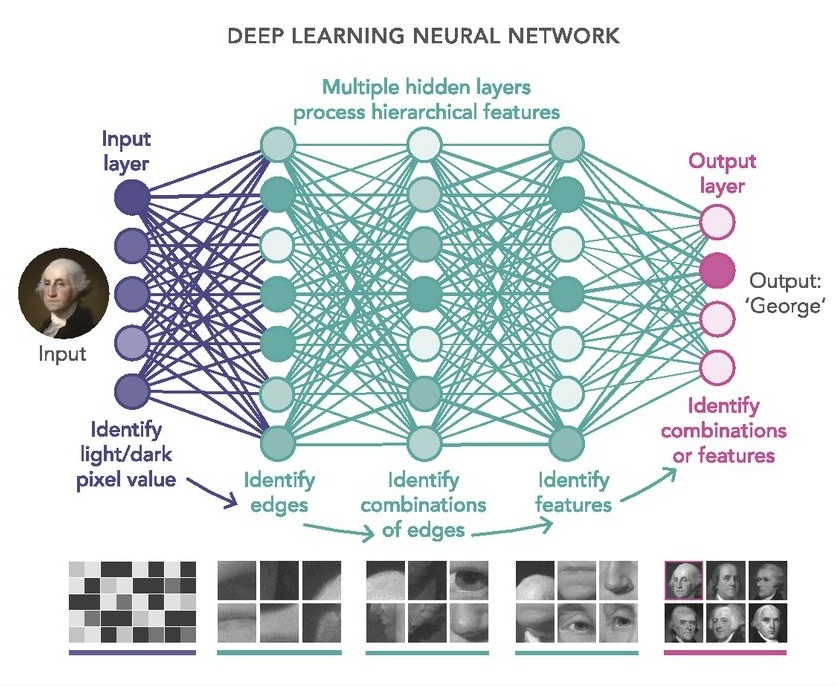
</div>

**3. Output Layer (Penthouse - Final Decision)**
- Produces the final prediction
- Structure depends on your problem:
  - **Regression:** 1 neuron, no activation (raw number output)
  - **Binary Classification:** 1 neuron, sigmoid activation (probability)
  - **Multi-class Classification:** N neurons (N = classes), softmax activation

In [3]:
# Code cell: Building Neural Network Architecture in Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

# Example: Breast cancer classification network
n_features = 30  # Input features (breast cancer dataset)

print("🏗️ Building Neural Network Architecture")
print("=" * 40)

# Initialize the Sequential model (our skyscraper foundation)
model = Sequential(name="BreastCancer_Classifier")

# Ground Floor: Input Layer (implicit - just data entry)
print("📥 Input Layer: 30 features (implicit in Keras)")

# Floor 1: Input Layer (Foundation)
model.add(Input(shape=(n_features,), name='input_layer'))
print("🏗️ Input Layer: Foundation ready")

# Floor 2: First Hidden Layer (Wide foundation)
model.add(Dense(
    units=32,                    # 32 neurons (wide start)
    activation='relu',           # ReLU activation function
    name='hidden_layer_1'        # Layer name for clarity
))
print("🏢 Hidden Layer 1: 32 neurons, ReLU activation")

# Floor 3: Second Hidden Layer (Narrowing funnel)
model.add(Dense(
    units=16,                    # 16 neurons (refinement)
    activation='relu',           # ReLU activation function
    name='hidden_layer_2'        # No input_shape needed
))
print("🏢 Hidden Layer 2: 16 neurons, ReLU activation")

# Penthouse: Output Layer (Final decision)
model.add(Dense(
    units=1,                     # 1 neuron for binary classification
    activation='sigmoid',        # Sigmoid for probabilities
    name='output_layer'
))
print("🏆 Output Layer: 1 neuron, Sigmoid activation")

🏗️ Building Neural Network Architecture
📥 Input Layer: 30 features (implicit in Keras)
🏗️ Input Layer: Foundation ready
🏢 Hidden Layer 1: 32 neurons, ReLU activation
🏢 Hidden Layer 2: 16 neurons, ReLU activation
🏆 Output Layer: 1 neuron, Sigmoid activation


### **🔗 Weights and Biases: The Learning Parameters**

In deep networks, we have **massive parameter counts**:
- **Every connection** between neurons has its own weight
- **Every neuron** in hidden and output layers has its own bias
- A deep network can have **millions** of these learnable parameters!

#### **📊 Architecture Design Principles**

##### **🔢 Understanding Parameter Calculations: The Mathematics Behind Deep Networks**

When we connect layers in a neural network, each connection requires learnable parameters. Understanding how to calculate these parameters is crucial for designing efficient architectures and debugging model complexity.

**Parameter Types in Dense Layers:**
- **Weights:** Connect every neuron in one layer to every neuron in the next layer
- **Biases:** One per neuron in the receiving layer (except input layer)

**Mathematical Foundation:**

For a Dense layer connection from Layer A (with `n` neurons) to Layer B (with `m` neurons):

**Weight Matrix Dimensions:** `n × m`
- Each of the `n` neurons in Layer A connects to each of the `m` neurons in Layer B
- Total weights = `n × m`

**Bias Vector Dimensions:** `m × 1` 
- Each neuron in Layer B has its own bias term
- Total biases = `m`

**Total Parameters for this connection:** `(n × m) + m = m × (n + 1)`

<div align="center">
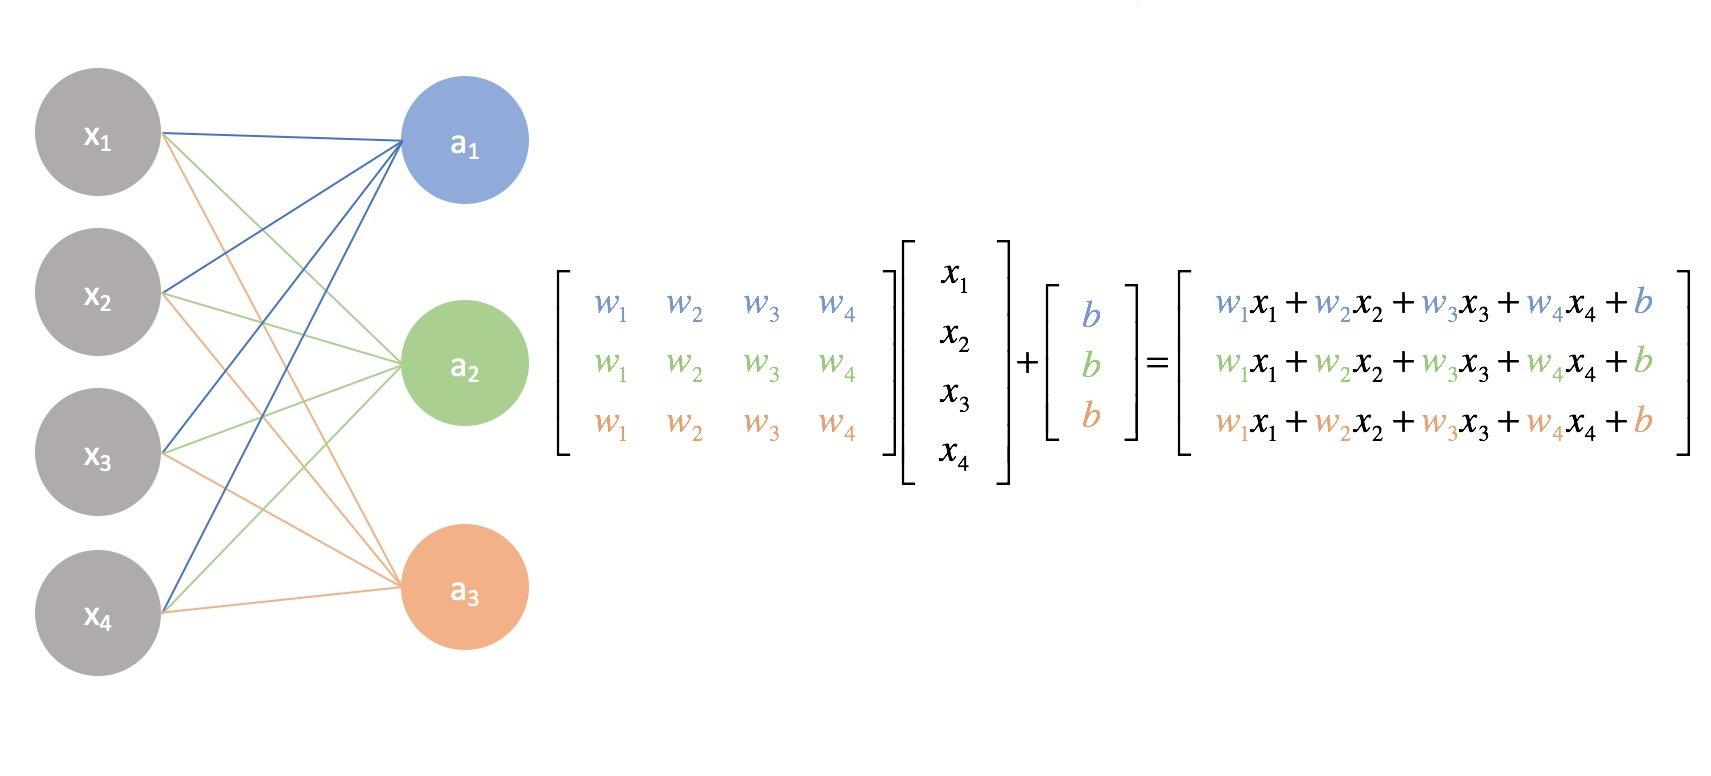
</div>

**Complete Network Parameter Calculation:**

For a network with layers of sizes: Input(I) → Hidden₁(H₁) → Hidden₂(H₂) → Output(O)

- **Layer 1 parameters:** `I × H₁ + H₁ = H₁ × (I + 1)`
- **Layer 2 parameters:** `H₁ × H₂ + H₂ = H₂ × (H₁ + 1)`
- **Layer 3 parameters:** `H₂ × O + O = O × (H₂ + 1)`

**Total Network Parameters:** `H₁(I + 1) + H₂(H₁ + 1) + O(H₂ + 1)`

**Why This Matters:**
- More parameters = more learning capacity but higher overfitting risk
- Parameter count determines memory usage and training time
- Understanding this helps you design appropriately sized architectures

Let's see this in action with a concrete example:

##### **🔍 Step-by-Step Parameter Calculation Breakdown**

Let's use a concrete example: **Input(30) → Hidden₁(32) → Hidden₂(16) → Output(1)**

**Understanding the Layer-by-Layer Connections:**

**🔗 Connection 1: Input(30) → Hidden₁(32)**
- **Weights needed:** Every input neuron connects to every hidden₁ neuron
  - 30 input neurons × 32 hidden₁ neurons = **960 weights**
- **Biases needed:** One bias per hidden₁ neuron = **32 biases**
- **Layer 1 total:** 960 + 32 = **992 parameters**
- **Formula:** `I × H₁ + H₁ = 30 × 32 + 32 = 32 × (30 + 1) = 32 × 31 = 992`

**🔗 Connection 2: Hidden₁(32) → Hidden₂(16)**
- **Weights needed:** Every hidden₁ neuron connects to every hidden₂ neuron
  - 32 hidden₁ neurons × 16 hidden₂ neurons = **512 weights**
- **Biases needed:** One bias per hidden₂ neuron = **16 biases**
- **Layer 2 total:** 512 + 16 = **528 parameters**
- **Formula:** `H₁ × H₂ + H₂ = 32 × 16 + 16 = 16 × (32 + 1) = 16 × 33 = 528`

**🔗 Connection 3: Hidden₂(16) → Output(1)**
- **Weights needed:** Every hidden₂ neuron connects to the output neuron
  - 16 hidden₂ neurons × 1 output neuron = **16 weights**
- **Biases needed:** One bias for the output neuron = **1 bias**
- **Layer 3 total:** 16 + 1 = **17 parameters**
- **Formula:** `H₂ × O + O = 16 × 1 + 1 = 1 × (16 + 1) = 1 × 17 = 17`

**🧮 Total Network Parameters:**
992 + 528 + 17 = **1,537 parameters**

**Using the general formula:**

`H₁(I + 1) + H₂(H₁ + 1) + O(H₂ + 1)`

= `32(30 + 1) + 16(32 + 1) + 1(16 + 1)`

= `32 × 31 + 16 × 33 + 1 × 17`

= `992 + 528 + 17 = 1,537` ✓

**🔑 Key Insight:** Each layer's parameters = (connections from previous layer) + (biases for current layer)

In [7]:
# Code cell demonstrating parameter calculation
import numpy as np

# Example: Simple 3-layer network for binary classification
input_features = 30  # e.g., breast cancer dataset
hidden1_neurons = 32
hidden2_neurons = 16
output_neurons = 1

# Calculate parameters manually
layer1_params = (input_features * hidden1_neurons) + hidden1_neurons  # weights + biases
layer2_params = (hidden1_neurons * hidden2_neurons) + hidden2_neurons
layer3_params = (hidden2_neurons * output_neurons) + output_neurons

total_params = layer1_params + layer2_params + layer3_params

print("🏗️ Architecture Design Decisions:")
print(f"   Input features: {input_features}")
print(f"   Hidden layer 1: {hidden1_neurons} neurons")
print(f"   Hidden layer 2: {hidden2_neurons} neurons")
print(f"   Output layer: {output_neurons} neuron(s)")
print(f"\n📊 Parameter Breakdown:")
print(f"   Layer 1 parameters: {layer1_params:,}")
print(f"   Layer 2 parameters: {layer2_params:,}")
print(f"   Layer 3 parameters: {layer3_params:,}")
print(f"   TOTAL PARAMETERS: {total_params:,}")
print(f"\n🤔 Compare to logistic regression: ~{input_features + 1} parameters")
print(f"   Complexity increase: {total_params // (input_features + 1)}x more powerful!")

🏗️ Architecture Design Decisions:
   Input features: 30
   Hidden layer 1: 32 neurons
   Hidden layer 2: 16 neurons
   Output layer: 1 neuron(s)

📊 Parameter Breakdown:
   Layer 1 parameters: 992
   Layer 2 parameters: 528
   Layer 3 parameters: 17
   TOTAL PARAMETERS: 1,537

🤔 Compare to logistic regression: ~31 parameters
   Complexity increase: 49x more powerful!


In [1]:
# Code cell: Building Neural Network Architecture in Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

In [ ]:
# Example: Breast cancer classification network
n_features = 30  # Input features (breast cancer dataset)

print("🏗️ Building Neural Network Architecture")
print("=" * 40)

# Initialize the Sequential model (our skyscraper foundation)
model = Sequential(name="BreastCancer_Classifier")

# Ground Floor: Input Layer (implicit - just data entry)
print("📥 Input Layer: 30 features (implicit in Keras)")

# Floor 1: Input Layer (Foundation)
model.add(Input(shape=(n_features,), name='input_layer'))
print("🏗️ Input Layer: Foundation ready")

# Floor 2: First Hidden Layer (Wide foundation)
model.add(Dense(
    units=32,                    # 32 neurons (wide start)
    activation='relu',           # ReLU activation function
    name='hidden_layer_1'        # Layer name for clarity
))
print("🏢 Hidden Layer 1: 32 neurons, ReLU activation")

# Floor 3: Second Hidden Layer (Narrowing funnel)
model.add(Dense(
    units=16,                    # 16 neurons (refinement)
    activation='relu',           # ReLU activation function
    name='hidden_layer_2'        # No input_shape needed
))
print("🏢 Hidden Layer 2: 16 neurons, ReLU activation")

# Penthouse: Output Layer (Final decision)
model.add(Dense(
    units=1,                     # 1 neuron for binary classification
    activation='sigmoid',        # Sigmoid for probabilities
    name='output_layer'
))
print("🏆 Output Layer: 1 neuron, Sigmoid activation")

🏗️ Building Neural Network Architecture
📥 Input Layer: 30 features (implicit in Keras)
🏗️ Input Layer: Foundation ready
🏢 Hidden Layer 1: 32 neurons, ReLU activation
🏢 Hidden Layer 2: 16 neurons, ReLU activation
🏆 Output Layer: 1 neuron, Sigmoid activation


In [5]:
# Display the complete architecture
print("\n📋 Complete Architecture Summary:")
model.summary()

# Architecture insights
print(f"\n🧠 Architecture Insights:")
print(f"   • Network depth: {len(model.layers)} layers")
print(f"   • Parameter count: {model.count_params():,}")
print(f"   • Architecture pattern: Funnel design (32 → 16 → 1)")


📋 Complete Architecture Summary:


Model: "BreastCancer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)               │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_2 (Dense)               │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)


🧠 Architecture Insights:
   • Network depth: 3 layers
   • Parameter count: 1,537
   • Architecture pattern: Funnel design (32 → 16 → 1)


In [5]:
# Build and compile a simple model to examine parameters
model = Sequential([
    Input(shape = (30,), name = "input_layer"),
    Dense(32, activation='relu', name='layer_1'),
    Dense(16, activation='relu', name='layer_2'),
    Dense(1, activation='sigmoid', name='output')
])

# Display the complete architecture
print("\n📋 Complete Architecture Summary:")
model.summary()


📋 Complete Architecture Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                      │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

#### 🏗️ Neural Network Architecture Guidelines: Best Practices Explained

<details>
<summary><b>🔢 Powers of 2 Convention (16, 32, 64, 128) - Click to expand</b></summary>

##### Why Powers of 2?

This is a solid and widely followed convention in machine learning that provides real benefits.

**Computational Efficiency:** Modern hardware, particularly GPUs and TPUs, is built on an architecture where memory is read and processed in chunks. The size of these chunks and the way parallel calculations are performed are optimized for numbers that are powers of two. When your layer sizes (and especially your batch size) align with these numbers, you get faster, more efficient training because the hardware is being used exactly as it was designed.

**Memory Alignment:** This is the technical reason behind the efficiency. It ensures that data structures fit neatly into the memory blocks of the hardware, preventing wasted space or the need for multiple, less efficient memory access cycles.

**Industry Standard:** This is absolutely true. If you read influential research papers (e.g., on models like VGG, ResNet, Transformers) or look at tutorials from major companies, you will see powers of two used everywhere.

**Implication:** Following this convention is like a "free" optimization. It helps your model train faster and makes your architecture more standard and comparable to others' work. While a network with 30 neurons will still work, one with 32 might be slightly faster for no extra effort.

</details>

<details>
<summary><b>🔽 Funnel Design (e.g., 32 → 16 → 1) - Click to expand</b></summary>

##### The Funnel Philosophy

This describes a standard architecture for many classification and regression tasks, especially with tabular data.

**Wide Start:** The first hidden layer receives the raw input features. A wider first layer gives the network enough "capacity" or "room" to learn many different combinations and interactions between these initial features. Starting too narrow can create an "information bottleneck" right away, choking the network before it can learn anything meaningful.

**Gradual Narrowing:** This is the key to the design. By forcing the network into progressively smaller layers, you are forcing it to compress information. It has to learn to distill the most important, predictive patterns from the previous layer and discard the noise. This process encourages the model to create more abstract and refined features as you go deeper.

**Focused Output:** The final layer is always dictated by your specific goal. A → 1 output layer is perfect for either binary classification (e.g., yes/no, fraud/not-fraud) using a sigmoid activation function, or a regression task (e.g., predicting a house price) using a linear activation.

**Implication:** This funnel structure helps the model generalize better. By forcing it to summarize and compress, it's less likely to "memorize" the training data (overfitting) and more likely to learn the underlying patterns that apply to new, unseen data.

</details>

<details>
<summary><b>📚 Hidden Layer Count Guidelines - Click to expand</b></summary>

##### How Many Layers Do You Need?

This provides excellent starting advice for choosing the depth of your network.

**2-3 Layers for Tabular Data:** The Universal Approximation Theorem proves that even one hidden layer is theoretically sufficient to approximate any function. In practice, 2 or 3 layers often provide a better balance of performance and efficiency for most tabular data problems. Tabular data (like spreadsheets or database tables) usually doesn't have the deep, hierarchical spatial structure that you'd find in an image.

**More Layers for Complex Patterns:** This is the core idea of Deep Learning. Data like images, human language (text), and audio have a natural hierarchy. For an image, layers learn pixels → edges → shapes (noses, eyes) → objects (faces). You need a deep network (many layers) to effectively model these layers of abstraction.

**Risk of Overfitting:** This is a crucial warning. A model with too many layers (and neurons) has a very high capacity. This means it can start to memorize the noise and specific quirks of your training data instead of learning the general trend. When this happens, it will perform brilliantly on the data it has seen but fail badly on new data.

**Implication:** The complexity of your model (its depth) should match the complexity of your data. Don't use a 100-layer ResNet to predict customer churn from a simple table; you'll likely overfit. Start simple (2-3 layers for tabular data) and only add complexity if necessary.

</details>

##### 🎯 Quick Reference Summary

- **Use powers of 2** for layer sizes (16, 32, 64, 128)
- **Funnel design** works well: wide → narrow → output
- **Start simple:** 2-3 layers for tabular data, more for complex patterns
- **Match complexity** to your data type and size

### **🧠 Knowledge Check Questions - Section 2.1.1**

**Question 1:** If you have a dataset with 50 features and want to build a network with hidden layers of 64 and 32 neurons for binary classification, how many total parameters will your model have?

<details>
<summary>Click for answer</summary>

Layer 1: (50 × 64) + 64 = 3,264 parameters  
Layer 2: (64 × 32) + 32 = 2,080 parameters  
Layer 3: (32 × 1) + 1 = 33 parameters  
**Total: 5,377 parameters**
</details>

**Question 2:** Why might a "funnel" architecture (decreasing neuron count) be better than an "expanding" architecture (increasing neuron count) for classification tasks?

<details>
<summary>Click for answer</summary>

Funnel architecture progressively refines and abstracts information from many features to fewer, more meaningful representations, culminating in a focused decision. Expanding architectures can lead to overfitting and inefficient learning.
</details>

**Question 3:** A neural network with how many hidden layers is considered "deep"?

<details>
<summary>Click for answer</summary>

**At least 1 hidden layer** makes a network "deep." Modern deep learning often uses dozens or hundreds of layers.
</details>

## **2.1.2 Feedforward Process: Information Flow**
*Estimated Time: 30 minutes*

### **The Data Highway: One-Way Traffic from Input to Output**

**Feedforward** is the process of data moving through the network to generate a prediction. It's a **one-way street** from input to output - no information flows backward (that's backpropagation, coming in Note 2.2!).

<div align="center">
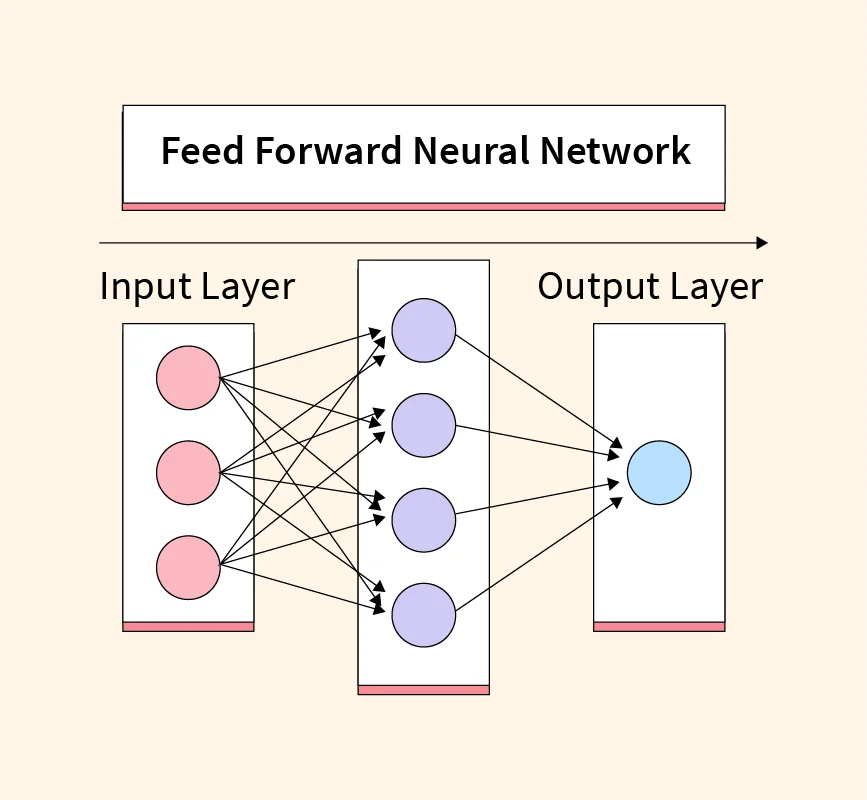
</div>

### **🚗 Step-by-Step Journey Through the Network**

Let's trace a single data point through our network:

In [2]:
# Code cell demonstrating feedforward concept
import numpy as np

# Simulate a simple feedforward pass
def demonstrate_feedforward():
    print("🚗 Feedforward Journey: One Data Point's Adventure")
    print("=" * 50)
    
    # Step 1: Input layer (just pass-through)
    input_data = np.array([0.5, -0.2, 1.3])  # 3 features for simplicity
    print(f"📥 INPUT LAYER:")
    print(f"   Raw features: {input_data}")
    print(f"   Action: Pass data to first hidden layer")
    
    # Step 2: First hidden layer
    print(f"\n🔄 HIDDEN LAYER 1 (4 neurons):")
    # Simplified weights and biases
    weights1 = np.random.randn(3, 4) * 0.5  # 3 inputs → 4 neurons
    biases1 = np.random.randn(4) * 0.1
    
    # Linear combination
    linear_output1 = np.dot(input_data, weights1) + biases1
    print(f"   Linear combination: {linear_output1.round(3)}")
    
    # Apply activation (ReLU)
    activated_output1 = np.maximum(0, linear_output1)  # ReLU
    print(f"   After ReLU activation: {activated_output1.round(3)}")
    
    # Step 3: Second hidden layer
    print(f"\n🔄 HIDDEN LAYER 2 (2 neurons):")
    weights2 = np.random.randn(4, 2) * 0.5  # 4 inputs → 2 neurons
    biases2 = np.random.randn(2) * 0.1
    
    linear_output2 = np.dot(activated_output1, weights2) + biases2
    print(f"   Linear combination: {linear_output2.round(3)}")
    
    activated_output2 = np.maximum(0, linear_output2)  # ReLU
    print(f"   After ReLU activation: {activated_output2.round(3)}")
    
    # Step 4: Output layer
    print(f"\n📤 OUTPUT LAYER (1 neuron - binary classification):")
    weights3 = np.random.randn(2, 1) * 0.5  # 2 inputs → 1 output
    bias3 = np.random.randn(1) * 0.1
    
    linear_output3 = np.dot(activated_output2, weights3) + bias3
    print(f"   Linear combination: {linear_output3.round(3)}")
    
    # Apply sigmoid for probability
    probability = 1 / (1 + np.exp(-linear_output3))  # Sigmoid
    print(f"   After sigmoid activation: {probability.round(3)}")
    print(f"   Final prediction: {'Positive' if probability > 0.5 else 'Negative'}")

# Run the demonstration
demonstrate_feedforward()

🚗 Feedforward Journey: One Data Point's Adventure
📥 INPUT LAYER:
   Raw features: [ 0.5 -0.2  1.3]
   Action: Pass data to first hidden layer

🔄 HIDDEN LAYER 1 (4 neurons):
   Linear combination: [ 0.565  0.584 -0.82   0.88 ]
   After ReLU activation: [0.565 0.584 0.    0.88 ]

🔄 HIDDEN LAYER 2 (2 neurons):
   Linear combination: [0.072 0.031]
   After ReLU activation: [0.072 0.031]

📤 OUTPUT LAYER (1 neuron - binary classification):
   Linear combination: [-0.085]
   After sigmoid activation: [0.479]
   Final prediction: Negative


### **🧠 What's Really Happening at Each Layer?**

**Mathematical Process (for each neuron):**
1. **Linear Combination:** `output = (input₁ × weight₁) + (input₂ × weight₂) + ... + bias`
2. **Activation Function:** `activated_output = activation_function(output)`
3. **Pass Forward:** This becomes input for the next layer

**Information Transformation:**
- **Raw features** → **Simple patterns** → **Complex patterns** → **Decision**
- Each layer **transforms** the representation to be more useful for the final task

### **🎭 Real-World Analogy: Assembly Line**

Think of feedforward like a **specialized assembly line**:

1. **Station 1 (Input):** Raw materials arrive
2. **Station 2 (Hidden Layer 1):** Workers detect basic components and patterns
3. **Station 3 (Hidden Layer 2):** Specialists combine components into sub-assemblies
4. **Station 4 (Output):** Final inspector makes the quality decision

Each station **specializes** in certain transformations, and the product gets **more refined** as it moves down the line.

### **⚡ Why This Matters for Deep Learning**

**Representation Learning:**
- Networks don't just memorize - they **learn useful representations**
- Each layer learns to **extract relevant features** for the task
- Deeper layers build **increasingly abstract concepts**

**Universal Approximation:**
- Deep networks can **approximate any function** (with enough neurons)
- The hierarchical structure makes learning **more efficient**
- This is why deep learning works for such diverse problems!

In [8]:
# Code cell: Complete Neural Network Demonstration (CORRECTED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
import numpy as np

print("🚀 Complete Neural Network Integration")
print("=" * 38)

# Step 1: Architecture Design
print("🏗️ STEP 1: Building Architecture")
model = Sequential([
    Dense(32, activation='relu', input_shape=(30,), name='feature_extraction'),
    Dense(16, activation='relu', name='pattern_refinement'), 
    Dense(1, activation='sigmoid', name='classification')
])

# Build the model by calling it with dummy data
dummy_input = np.zeros((1, 30))
_ = model(dummy_input)  # This builds the model

print(f"   ✅ Architecture: 30 → 32 → 16 → 1")
print(f"   ✅ Total parameters: {model.count_params():,}")

# Step 2: Parameter Examination
print(f"\n🔍 STEP 2: Parameter Analysis")
for i, layer in enumerate(model.layers):
    w, b = layer.get_weights()
    print(f"   Layer {i+1}: {w.shape[0]}×{w.shape[1]} weights + {b.shape[0]} biases = {w.size + b.size} params")

# Step 3: Create Sample Data
print(f"\n📊 STEP 3: Sample Data Preparation")
# Simulate breast cancer features (30 features, 5 samples)
np.random.seed(42)
X_sample = np.random.randn(5, 30)
print(f"   ✅ Sample data shape: {X_sample.shape}")

# Step 4: Feedforward Demonstration
print(f"\n🔄 STEP 4: Complete Feedforward Process")

# Create intermediate models for layer-by-layer analysis
layer1_model = Model(inputs=model.input, outputs=model.layers[0].output)
layer2_model = Model(inputs=model.input, outputs=model.layers[1].output) 
full_model = model

# Process one sample through each layer
sample = X_sample[0:1]  # First sample only

# Layer-by-layer processing
activations = {}
activations['input'] = sample
activations['hidden1'] = layer1_model.predict(sample, verbose=0)
activations['hidden2'] = layer2_model.predict(sample, verbose=0)
activations['output'] = full_model.predict(sample, verbose=0)

# Display the complete flow
for layer_name, activation in activations.items():
    if layer_name == 'output':
        active_neurons = 'N/A (probability)'
    else:
        active_neurons = np.sum(activation > 0) if layer_name != 'input' else 'N/A (input)'
    print(f"   {layer_name.upper()}: {activation.shape} | Active neurons: {active_neurons}")

# Step 5: Architecture Visualization
print(f"\n📈 STEP 5: Architecture Summary")
model.summary()

# Step 6: Batch Prediction Demonstration
print(f"\n🎯 STEP 6: Batch Processing")
all_predictions = full_model.predict(X_sample, verbose=0)
print(f"   Input: {X_sample.shape} → Output: {all_predictions.shape}")
print(f"   Predictions: {all_predictions.flatten().round(4)}")

# Step 7: Key Insights
print(f"\n💡 KEY INSIGHTS:")
print(f"   🏗️ Architecture defines information flow")
print(f"   🔢 Parameters store learned patterns") 
print(f"   🔄 Feedforward transforms input to prediction")
print(f"   📊 Each layer creates more abstract representations")
print(f"   🎯 Final layer produces task-specific output")

print(f"\n✅ Integration Complete: Ready for training!")

🚀 Complete Neural Network Integration
🏗️ STEP 1: Building Architecture
   ✅ Architecture: 30 → 32 → 16 → 1
   ✅ Total parameters: 1,537

🔍 STEP 2: Parameter Analysis
   Layer 1: 30×32 weights + 32 biases = 992 params
   Layer 2: 32×16 weights + 16 biases = 528 params
   Layer 3: 16×1 weights + 1 biases = 17 params

📊 STEP 3: Sample Data Preparation
   ✅ Sample data shape: (5, 30)

🔄 STEP 4: Complete Feedforward Process


AttributeError: The layer sequential_5 has never been called and thus has no defined input.

### **🧠 Knowledge Check Questions - Section 2.1.2**

**Question 1:** In feedforward, does information ever flow backward through the network during prediction?

<details>
<summary>Click for answer</summary>

**No!** Feedforward is strictly one-way: input → hidden layers → output. Information only flows backward during training (backpropagation), not during prediction.
</details>

**Question 2:** If a hidden layer has 3 neurons and receives input from 5 neurons in the previous layer, how many mathematical operations occur in this layer (ignoring the activation function)?

<details>
<summary>Click for answer</summary>

Each of the 3 neurons performs: (5 multiplications + 5 additions + 1 bias addition) = 11 operations per neuron.  
Total: **3 × 11 = 33 operations** (plus 3 activation function applications).
</details>

**Question 3:** Why do we apply activation functions after the linear combination in each layer?

<details>
<summary>Click for answer</summary>

Without activation functions, multiple linear layers would collapse into a single linear transformation (linear combinations of linear functions are still linear). Activation functions introduce **non-linearity**, enabling the network to learn complex patterns and approximate any function.
</details>

**Question 4:** Complete this feedforward sequence: Raw Data → Hidden Layer 1 → ? → ? → Final Prediction

<details>
<summary>Click for answer</summary>

Raw Data → Hidden Layer 1 → **Hidden Layer 2** → **Output Layer** → Final Prediction  
(Note: The number of hidden layers can vary, but there's always at least one hidden layer in a deep network)
</details>

## **📝 Summary & Transition to Note 2.2**

### **🎯 What We've Mastered in Note 2.1:**

✅ **Deep Network Architecture:** Understanding layers, neurons, and connections  
✅ **Parameter Complexity:** How deep networks have vastly more learning capacity  
✅ **Feedforward Process:** How information flows through the network for predictions  
✅ **Hierarchical Learning:** How layers build increasingly complex representations  

### **🔗 The Big Picture So Far:**

We now understand **how deep networks are structured** and **how they make predictions**. But a crucial question remains unanswered:

🤔 **"The network made a prediction... but how does it know if that prediction was good or bad? And if it was wrong, how does it figure out what to fix?"**

### **🚀 Coming Up in Note 2.2: Learning Mechanisms**

Tomorrow's burning questions we'll answer:
- **How do we measure "wrongness"?** → Loss Functions
- **How does the network figure out what went wrong?** → Backpropagation  
- **What's the mathematical magic behind learning?** → Gradient-based learning

**The Journey Continues:** We've built our neural skyscraper... now let's teach it how to learn! 🧠⚡

**⏰ Time Check:** Note 2.1 Complete (1.0 hour)  
**🎯 Next:** Note 2.2 - Learning Mechanisms (1.0 hour)  
**📈 Progress:** 1/4 notes complete for Day 2